In [355]:
%matplotlib inline
import os
import numpy as np
from typing import _TypedDict, Dict
import yaml
import functools

import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from tampanda import ArmSceneBuilder, RRTStar, GraspPlanner, PickPlaceExecutor
from tampanda.scenes import TABLE_SYMBOLIC_TEMPLATE, BLOCK_SMALL_TEMPLATE
from tampanda.tamp import DomainBridge
from tampanda.symbolic.domains.blocks.blocks_domain import BlocksDomain
from tampanda.planners.grasp_planner import GraspType, GRASP_CONTACT_OFFSET


In [356]:
import os
if "DISPLAY" in os.environ:
    del os.environ["DISPLAY"]
os.environ["MUJOCO_GL"] = "egl"
os.environ["DISPLAY"] = ":3"

In [357]:
# ── Visualisation helpers (provided) ──────────────────────────────────────────
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam
def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img
def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)
def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()
def _table_center():
    try: return ((BOUNDS["min_x"]+BOUNDS["max_x"])/2, (BOUNDS["min_y"]+BOUNDS["max_y"])/2, BOUNDS["table_height"])
    except NameError: return (0.4, 0.4, 0.27)
def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25):
    _show(_render(env, _free_cam(env, _table_center(), distance, azimuth, elevation)), title)
def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center(), distance, 90, -89)), title)
def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)
def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")
print("Visualisation helpers ready ✓")

Visualisation helpers ready ✓


In [358]:
def euler_to_quaternion(x_deg, y_deg, z_deg):
    x = np.radians(x_deg) / 2
    y = np.radians(y_deg) / 2
    z = np.radians(z_deg) / 2
    
    cx, sx = np.cos(x), np.sin(x)
    cy, sy = np.cos(y), np.sin(y)
    cz, sz = np.cos(z), np.sin(z)
    qx = sx * cy * cz - cx * sy * sz
    qy = cx * sy * cz + sx * cy * sz
    qz = cx * cy * sz - sx * sy * cz
    qw = cx * cy * cz + sx * sy * sz
    
    return [qx, qy, qz, qw]

### Setting up TamPanda environment (using ArmsceneBuilder and custom Blocks) from WorkBenchMark yaml problem files
Probably have to rewrite this to adhere to ground truth yaml files from the other WorkBenchMark folder that I just found

In [359]:
# In the later DomainBridge, for action PLACE, we need some defined locatations to place blocks
# We start with the following locations (only consider ground level, others are only relevant to stack-action): 
# Any spot where a brick is to be placed in the goal
# Any spot where a brick starts out in the intial ground truth
# Maybe 2 locations that are further off, in order to place bricks temporarily
LOCATIONS: Dict[str, Dict] = {}

Initial positions: 
[{'name': '4x2_brick_1', 'type': 'brick_4x2', 'color': 'red', 'pos': [0.4994, -0.1206, 0.0495], 'rotation': [0, 0, 0]}, {'name': '2x2_brick_2', 'type': 'brick_2x2', 'color': 'green', 'pos': [0.3888, -0.109, 0.0495], 'rotation': [0, 0, 0]}, {'name': '4x2_brick_3', 'type': 'brick_4x2', 'color': 'green', 'pos': [0.2507, -0.12, 0.0495], 'rotation': [0, 0, 0]}]
Goal positions: 
[{'name': '4x2_brick_1', 'type': 'brick_4x2', 'color': 'red', 'pos': [0.0, 0.148, 0.0], 'rotation': [0, 0, 0]}, {'name': '2x2_brick_2', 'type': 'brick_2x2', 'color': 'green', 'pos': [-0.016, 0.148, 0.0191], 'rotation': [0, 0, 90]}, {'name': '4x2_brick_3', 'type': 'brick_4x2', 'color': 'green', 'pos': [0.0, 0.148, 0.0382], 'rotation': [0, 0, 0]}]
[0.4994, -0.1206, 0.0495]
[0.3888, -0.109, 0.0495]
[0.2507, -0.12, 0.0495]
[0.0, 0.148, 0.0]
[-0.016, 0.148, 0.0191]
[0.0, 0.148, 0.0382]
{'min_x': np.float64(-0.09999999999999998), 'max_x': np.float64(0.9), 'min_y': np.float64(0.20000000000000007), 'max_y

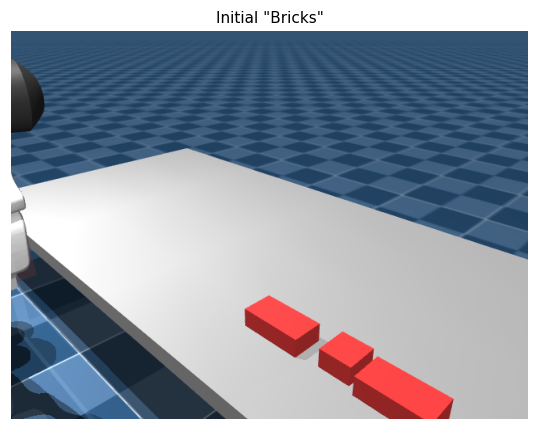

In [ ]:

with open('dataset/ground_truth/tier2/task_069.yaml', 'r') as file:
    yaml_content = file.read()


product_data = yaml.safe_load(yaml_content)
initial_blocks_info = product_data.get('initial_blocks', [])

with open('dataset/benchmark_tasks/tier2/task_069.yaml', 'r') as file:
    yaml_content = file.read()


product_data = yaml.safe_load(yaml_content)
goal_blocks_info = product_data.get('blocks', [])


print("Initial positions: ")
print(initial_blocks_info)
print("Goal positions: ")
print(goal_blocks_info)


builder = ArmSceneBuilder()
builder.add_resource("table", TABLE_SYMBOLIC_TEMPLATE)
#TODO: Check workbenchmark Tier 1 and 2 regarding other potential block types
builder.add_resource("block_2x2", "block_templates/brick_2x2.xml") 
builder.add_resource("block_4x2", "block_templates/brick_4x2.xml") 

builder.add_object("table", name="table", pos=[0.0, 0.4, 0.0], quat=[0.0, 0.0, 0.0, 1.0])




BLOCKS = []
for i, brick in enumerate(initial_blocks_info):
    # Add a b to the name because apparently object names may not start with numbers..
    brick['name'] = "b"+brick['name']
    block_name = brick['name']
    if brick['type'] == 'brick_2x2':
        builder_name = "block_2x2"
    elif brick['type'] == 'brick_4x2':
        builder_name = "block_4x2"
    else:
        builder_name = "block_2x2"
        print("Warning: Block type not known!")

    init_pos = brick['pos']
    print(init_pos)
    quat = euler_to_quaternion(brick["rotation"][0], brick["rotation"][1], brick["rotation"][2])
    builder.add_object(builder_name, name=block_name, pos=init_pos, quat=quat)

    loc_name = "initial_loc_" + block_name
    # max_x and so forth must be adjusted to block dimensions and rotations, leave them for now and just work with radius instead as approximation
    LOCATIONS[loc_name] = {"center": init_pos, "footprint": builder_name, "quat": quat, "min_x": init_pos[0]-0.016, "max_x": init_pos[0]+0.016, "min_y": init_pos[1]-0.016, "max_y": init_pos[1]+0.016, "radius": 0.016}
    BLOCKS.append(block_name)

GOALS = []
for i, brick in enumerate(goal_blocks_info):
    # Add a b to the name because apparently object names may not start with numbers..
    brick['name'] = "b"+brick['name']
    block_name = brick['name']

    if brick['type'] == 'brick_2x2':
        builder_name = "block_2x2"
    elif brick['type'] == 'brick_4x2':
        builder_name = "block_4x2"
    else:
        builder_name = "block_2x2"
        print("Warning: Block type not known!")
    final_pos = brick['pos']
    print(final_pos)
    quat = euler_to_quaternion(brick["rotation"][0], brick["rotation"][1], brick["rotation"][2])
    loc_name = "goal_loc_" + block_name
    LOCATIONS[loc_name] = {"center": final_pos, "footprint": builder_name, "quat": quat, "min_x": final_pos[0]-0.016, "max_x": final_pos[0]+0.016, "min_y": final_pos[1]-0.016, "max_y": final_pos[1]+0.016, "radius": 0.016}
    GOALS.append(("at", block_name, loc_name))

env = builder.build_env(rate=200.0)

domain = BlocksDomain(env.model, table_geom_name="table_surface", working_area=(1,1))
BOUNDS = domain.get_working_bounds()
print(BOUNDS)
table_height = BOUNDS["table_height"]
table_center_x = (BOUNDS["max_x"]-BOUNDS["min_x"])/2
table_center_y = (BOUNDS["max_y"]-BOUNDS["min_y"])/2
print(table_center_x)
print(table_center_y)
    
if len(initial_blocks_info) > 0:
    first_block_name = initial_blocks_info[0]['name']
    BLOCK_HALF = env.get_object_half_size(first_block_name)
    
    for i, brick in enumerate(initial_blocks_info):
        block_name = brick['name']
        print(block_name)
        print(brick['pos'])
        init_x = table_center_x + brick['pos'][0] 
        init_y = table_center_y + brick['pos'][1]
        init_z = table_height + brick['pos'][2]
        
        env.set_object_pose(block_name, np.array([init_x, init_y, init_z]))

env.reset_velocities()
env.forward()
env.rest(0.5)

show_scene(env, "Initial \"Bricks\"")

In [361]:
# ── Task 3: generate grasp configurations ─────────────────────────────────────
grasp_planner = GraspPlanner(table_z=table_height)
GRASP_CONFIGS: Dict[str, Dict] = {}
# TODO: for each block, generate candidates and store them as cfg_{block}_{i}.
for block in BLOCKS:
    # https://snoato.github.io/TAMPanda/tutorial.html#grasp
    pos = env.get_object_position(block)
    half = env.get_object_half_size(block)
    quat = env.get_object_orientation(block)
    candidates = grasp_planner.generate_candidates(pos, half, quat)
    for i, candidate in enumerate(candidates):
        GRASP_CONFIGS[f"cfg_{block}_{i}"] = {"block": block, "candidate": candidate}
    
print("total configs:", len(GRASP_CONFIGS))

total configs: 0


In [362]:
# ── Task 4.0: implement the gripper-corridor test ────────────────────────────
CLEAR, ALIGN = 0.10, 0.045     # finger-corridor length / lateral tolerance (m)
def corridor_blocked(env, other, block, gtype):
    """True if `other` sits in `block`'s gripper corridor for a `gtype` top-down grasp.
    TOP_DOWN_X closes along X (block if dx < CLEAR and dy < ALIGN);
    TOP_DOWN_Y closes along Y (block if dy < CLEAR and dx < ALIGN)."""
    
    # other blocks the grasp if it is within CLEAR along the closing axis and within ALIGN on the perpendicular axis
    other_pos = env.get_object_position(other)
    block_pos = env.get_object_position(block)

    dx = abs(other_pos[0] - block_pos[0])
    dy = abs(other_pos[1] - block_pos[1])

    if gtype == GraspType.TOP_DOWN_X:      # fingers close along X
        return dx < CLEAR and dy < ALIGN
    elif gtype == GraspType.TOP_DOWN_Y:    # fingers close along Y
        return dy < CLEAR and dx < ALIGN

# Now onto the DomainBridge...

In [363]:
# ── Task 4: implement the geometric predicates ────────────────────────────────
def eval_ik_feasible(env, fluents, config: str) -> bool:
    # TODO: True iff no other block is in this config's grasp corridor.
    cfg = GRASP_CONFIGS[config]
    block = cfg["block"]
    gtype = cfg["candidate"].grasp_type
    others = [b for b in BLOCKS if b != block]
    return not any(corridor_blocked(env, o, block, gtype) for o in others)

def eval_accessible(env, fluents, item: str) -> bool:
    # TODO: True iff `item` has at least one ik-feasible config.
    return any(eval_ik_feasible(env, fluents, key) for key, cfg in GRASP_CONFIGS.items() if cfg["block"] == item)

def eval_obstructs(env, fluents, a: str, b: str) -> bool:
    # TODO: True iff a != b and a blocks at least one of b's grasp corridors.
    if a == b:
        return False
    # check if any block b in one of a's grasp corridors
    return any(corridor_blocked(env, a, b, cfg["candidate"].grasp_type) for key, cfg in GRASP_CONFIGS.items() if cfg["block"] == b)

def eval_place_free(env, fluents, item: str, location: str) -> bool:
    # TODO: True iff the location is a SAFE drop spot for `item`:
    #   (a) no other block is within 0.05 m of LOCATIONS[location]["center"] (collision), AND
    #   (b) a block placed at that centre would NOT sit in any other block's grasp corridor
    #       (reuse corridor_blocked-style logic: dx<CLEAR & dy<ALIGN, or dy<CLEAR & dx<ALIGN).
    for block in BLOCKS:
        if block == item:
            continue
            
        block_pos = env.get_object_position(block)
        safe_pos = LOCATIONS[location]["center"]

        dx = abs(safe_pos[0] - block_pos[0])
        dy = abs(safe_pos[1] - block_pos[1])

        if np.sqrt(dx**2 + dy**2) <= 0.05:
            return False

        # getting the grasp types that block's grasp corridors have
        gtypes = {cfg["candidate"].grasp_type for key, cfg in GRASP_CONFIGS.items() if cfg["block"] == block}

        # return false if any grasp corridor of block obstructed by item having moved
        if GraspType.TOP_DOWN_X in gtypes and dx < CLEAR and dy < ALIGN:      # fingers close along X
            return False
        if GraspType.TOP_DOWN_Y in gtypes and dy < CLEAR and dx < ALIGN:    # fingers close along Y
            return False

    return True

def eval_at(env, fluents, item: str, location: str) -> bool:
    p = env.get_object_position(item); loc = LOCATIONS[location]
    
    
    return bool(np.linalg.norm(p[:2] - loc["center"][:2]) <= loc["radius"])
def eval_clear(env, fluents, location: str) -> bool:
    return not any(eval_at(env, fluents, x, location) for x in BLOCKS)

print("accessible:", {o: eval_accessible(env, {}, o) for o in BLOCKS})  # fill in after implementing

accessible: {'b4x2_brick_1': False, 'b2x2_brick_2': False, 'b4x2_brick_3': False}


In [364]:
# ── Bridge, predicates, fluents, helpers (provided) ───────────────────────────
planner = RRTStar(env); planner.max_iterations = 2000; planner.step_size = 0.15
bridge = DomainBridge("pddl/coarse/lego_coarse2.pddl", env)
bridge.plan = functools.partial(type(bridge).plan, bridge, planner_name="pyperplan")  # reproducible engine

bridge.predicate("at")(eval_at)
bridge.predicate("loc_clear")(eval_clear)
bridge.predicate("place-free")(eval_place_free)
bridge.predicate("config-for")(lambda e, fl, c, o: GRASP_CONFIGS.get(c, {}).get("block") == o)
bridge.predicate("ik-feasible")(eval_ik_feasible)
bridge.predicate("accessible")(eval_accessible)
bridge.predicate("obstructs")(eval_obstructs)
bridge.fluent("hand-empty", initial=True); bridge.fluent("holding")

def feasible_config(env, item):
    """A grasp candidate for `item` that is collision-free in the current scene (or None)."""
    for c in GRASP_CONFIGS:
        if GRASP_CONFIGS[c]["block"] == item and eval_ik_feasible(env, {}, c):
            return GRASP_CONFIGS[c]["candidate"]
    return None

print("predicates:", bridge.predicate_names)

predicates: ['shape', 'is_color', 'at', 'stacked_on', 'loc_clear', 'brick_clear', 'holding', 'hand-empty', 'place-free', 'config-for', 'ik-feasible', 'accessible', 'obstructs']


### DomainBridge Action Implementations:

In [365]:
@bridge.action("pick")
def exec_pick(env, fluents, item: str, location: str, config: str):
    cand = feasible_config(env, item)  # current feasible grasps of item

    if cand is None:
        return (False, {})
        
    # to approach_pos
    path = planner.plan_to_pose(target_pos=cand.approach_pos, target_quat=cand.grasp_quat)
    if path is None:
        return (False, {})
    env.execute_path(path, planner)
    env.wait_idle()
    env.add_collision_exception(item)  # collision checker does not treat item as obstacle

    # to grasp_pos
    path = planner.plan_to_pose(target_pos=cand.grasp_pos, target_quat=cand.grasp_quat)
    if path is None:
        env.remove_collision_exception(item)
        return (False, {})
    env.execute_path(path, planner)
    env.wait_idle()

    # close gripper
    env.controller.close_gripper()
    env.attach_object_to_ee(item)

    # to lift_pos
    path = planner.plan_to_pose(target_pos=cand.lift_pos, target_quat=cand.grasp_quat)
    if path is None:
        env.remove_collision_exception(item)
        return (False, {})
    env.execute_path(path, planner)
    env.wait_idle()

    env.remove_collision_exception(item)

    # FIXME: why saying holding with config even though we use cand (ie some feasible config, not one binded by pyperplan)
    return (True, {("holding", item, config): True, ("hand-empty",): False})

In [366]:
# Define more LOCATIONS, for instance two intermediate ones to place the block if others obstructed/overlapping!


In [367]:
@bridge.action("place")
def exec_place(env, fluents, item: str, location: str, config: str):
    
    cand = GRASP_CONFIGS[config]["candidate"]  # specific config which the symbolic-planner picked
    ee_z = table_height + BLOCK_HALF[2] + GRASP_CONTACT_OFFSET + 0.003
    xy = LOCATIONS[location]["center"]
    above_pos = np.array([xy[0], xy[1], ee_z + 0.12])
    place_pos = np.array([xy[0], xy[1], ee_z])
    
    env.add_collision_exception(item)

    # to above_pos (above location)
    path = planner.plan_to_pose(target_pos=above_pos, target_quat=cand.grasp_quat)
    if path is None:
        env.remove_collision_exception(item)
        return (False, {})
    env.execute_path(path, planner)
    env.wait_idle()

    # to place_pos (on table at location)
    path = planner.plan_to_pose(target_pos=place_pos, target_quat=cand.grasp_quat)
    if path is None:
        env.remove_collision_exception(item)
        return (False, {})
    env.execute_path(path, planner)
    env.wait_idle()

    # item from gripper on table
    env.detach_object()
    env.controller.open_gripper()
    env.wait_idle()
    
    env.remove_collision_exception(item)

    return (True, {("holding", item, config): False, ("hand-empty",): True})

In [368]:
@bridge.action("pick-to-clear")
def exec_pick_to_clear(env, fluents, item, location, config, blocked):
    success, deltas = exec_pick(env, fluents, item, location, config)
    if not success:
        return (False, {})

    return (True, {**deltas, ("obstructs", item, blocked): False})

In [369]:
@bridge.action("stack")
def exec_stack(env, fluents, item1: str, item2: str, location: str, config: str):
    ... #TODO This first implementation, due to the simplistic domain, only allows exact stacking, i.e. the loc of the top brick must be the same as that of the bottom (precisely, the respective centers)
    # Also, we initially restrict ourselves to a height limit of 2 bricks.
    cand = GRASP_CONFIGS[config]["candidate"]  # specific config which the symbolic-planner picked
    ee_z = table_height + 3 * BLOCK_HALF[2] + GRASP_CONTACT_OFFSET + 0.003
    xy = LOCATIONS[location]["center"]
    above_pos = np.array([xy[0], xy[1], ee_z + 0.12])
    place_pos = np.array([xy[0], xy[1], ee_z])
    
    env.add_collision_exception(item1)

    # to above_pos (above location)
    path = planner.plan_to_pose(target_pos=above_pos, target_quat=cand.grasp_quat)
    if path is None:
        env.remove_collision_exception(item1)
        return (False, {})
    env.execute_path(path, planner)
    env.wait_idle()

    # to place_pos (on table at location)
    path = planner.plan_to_pose(target_pos=place_pos, target_quat=cand.grasp_quat)
    if path is None:
        env.remove_collision_exception(item1)
        return (False, {})
    env.execute_path(path, planner)
    env.wait_idle()

    # item from gripper on table
    env.detach_object()
    env.controller.open_gripper()
    env.wait_idle()
    
    env.remove_collision_exception(item1)

    return (True, {("holding", item1, config): False, ("hand-empty",): True, ("at", item1, location): True, ("accessible", item2): False, ("obstructs", item1, item2): True})

# TAMP Loop

true facts:
   ('hand-empty',)
   ('loc_clear', 'goal_loc_2x2_brick_2')
   ('loc_clear', 'goal_loc_4x2_brick_1')
   ('loc_clear', 'goal_loc_4x2_brick_3')
   ('loc_clear', 'initial_loc_b2x2_brick_2')
   ('loc_clear', 'initial_loc_b4x2_brick_1')
   ('loc_clear', 'initial_loc_b4x2_brick_3')
   ('place-free', 'b2x2_brick_2', 'goal_loc_2x2_brick_2')
   ('place-free', 'b2x2_brick_2', 'goal_loc_4x2_brick_1')
   ('place-free', 'b2x2_brick_2', 'goal_loc_4x2_brick_3')
   ('place-free', 'b2x2_brick_2', 'initial_loc_b2x2_brick_2')
   ('place-free', 'b2x2_brick_2', 'initial_loc_b4x2_brick_1')
   ('place-free', 'b2x2_brick_2', 'initial_loc_b4x2_brick_3')
   ('place-free', 'b4x2_brick_1', 'goal_loc_2x2_brick_2')
   ('place-free', 'b4x2_brick_1', 'goal_loc_4x2_brick_1')
   ('place-free', 'b4x2_brick_1', 'goal_loc_4x2_brick_3')
   ('place-free', 'b4x2_brick_1', 'initial_loc_b2x2_brick_2')
   ('place-free', 'b4x2_brick_1', 'initial_loc_b4x2_brick_1')
   ('place-free', 'b4x2_brick_1', 'initial_loc_b4x2_b

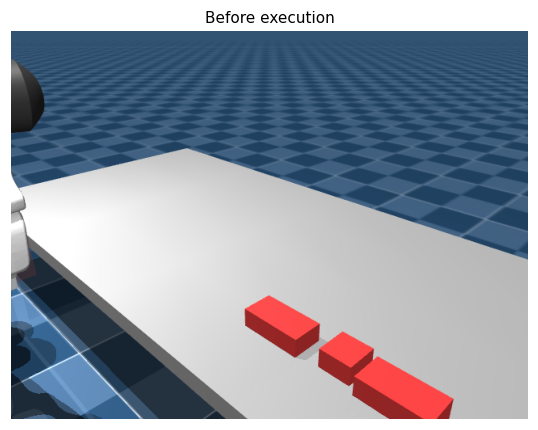

In [370]:
# ── Objects, goal, grounded state (provided) ──────────────────────────────────
OBJECTS = {"brick": BLOCKS, "location": list(LOCATIONS), "grasp-config": list(GRASP_CONFIGS)}
# GOALS are defined way above, for reference
state = bridge.ground_state(OBJECTS)
print("true facts:")
for k in sorted(k for k, v in state.items() if v): print("  ", k)
show_scene(env, "Before execution")

In [372]:
viewer = env.launch_viewer()
print(OBJECTS)
print(GOALS)
for i in range(4):
    plan = bridge.plan(OBJECTS, GOALS)
    print(f"--- attempt {i}: plan = {plan}")
    if plan is None:
        continue

    for action, params in plan:
        success, delta = bridge.execute_action(action, *params)
        print(f"    {action}({', '.join(params)}) -> {success}")
        if not success:
            break

    if eval_at(env, {}, "block_0", "loc_goal"):
        break

final = bridge.ground_state(OBJECTS)
print("Goal achieved:", all(final.get(g, False) for g in GOALS))
show_scene(env, "After execution")

{'brick': ['b4x2_brick_1', 'b2x2_brick_2', 'b4x2_brick_3'], 'location': ['initial_loc_b4x2_brick_1', 'initial_loc_b2x2_brick_2', 'initial_loc_b4x2_brick_3', 'goal_loc_4x2_brick_1', 'goal_loc_2x2_brick_2', 'goal_loc_4x2_brick_3'], 'grasp-config': []}
[('at', '4x2_brick_1', 'goal_loc_4x2_brick_1'), ('at', '2x2_brick_2', 'goal_loc_2x2_brick_2'), ('at', '4x2_brick_3', 'goal_loc_4x2_brick_3')]


SyntaxError: Found invalid expression: 4x2_brick_3. From line: 37, col 7 to line: 37, col 18 (<string>)